In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
con = duckdb.connect('/content/drive/My Drive/CIS2450 Final Project/Models/flight_data.duckdb')
con.execute("ATTACH '/content/drive/My Drive/CIS2450 Final Project/Models/weather_data.duckdb' AS weather_db")

Mounted at /content/drive


In [2]:
# To get the schema of a table, you can use the DESCRIBE command
con.execute("DESCRIBE flights_cleaned").fetchdf()

,column_name,column_type,null,key,default,extra
0,YEAR,BIGINT,YES,None,None,None
1,MONTH,BIGINT,YES,None,None,None
2,DAY_OF_MONTH,BIGINT,YES,None,None,None
3,OP_CARRIER_AIRLINE_ID,BIGINT,YES,None,None,None
4,OP_CARRIER_FL_NUM,DOUBLE,YES,None,None,None
5,ORIGIN_AIRPORT_ID,BIGINT,YES,None,None,None
6,ORIGIN,VARCHAR,YES,None,None,None
7,DEST_AIRPORT_ID,BIGINT,YES,None,None,None
8,DEST,VARCHAR,YES,None,None,None
9,CRS_DEP_TIME,BIGINT,YES,None,None,None


In [3]:
con.execute("DESCRIBE weather_db.weather_cleaned").fetchdf()

,column_name,column_type,null,key,default,extra
0,STATION,VARCHAR,YES,None,None,None
1,valid_ts,TIMESTAMP,YES,None,None,None
2,YEAR,BIGINT,YES,None,None,None
3,MONTH,BIGINT,YES,None,None,None
4,DAY,BIGINT,YES,None,None,None
5,HOUR,BIGINT,YES,None,None,None
6,WIND_ANGLE,DOUBLE,YES,None,None,None
7,WIND_SPEED,DOUBLE,YES,None,None,None
8,WIND_GUST,DOUBLE,YES,None,None,None
9,VISIBILITY,DOUBLE,YES,None,None,None


CLEANING THE DATA (copied from baseline model)

In [4]:
query = """
SELECT
    f.MONTH,
    f.DAY_OF_MONTH,
    f.DISTANCE,
    CAST(f.CRS_DEP_TIME / 100 AS BIGINT) AS DEP_HOUR,

    -- All Weather Features included with logical imputations
    COALESCE(w.WIND_SPEED, 0) AS WIND_SPEED,
    COALESCE(w.WIND_GUST, 0) AS WIND_GUST,
    COALESCE(w.WIND_ANGLE, 0) AS WIND_ANGLE,
    COALESCE(w.VISIBILITY, 10) AS VISIBILITY,
    COALESCE(w.AIR_TEMP, 20) AS AIR_TEMP,
    COALESCE(w.DEW_POINT_TEMP, w.AIR_TEMP) AS DEW_POINT_TEMP, -- Default to air temp if missing
    COALESCE(w.PRESSURE, 1013.25) AS PRESSURE, -- Standard atmospheric pressure
    COALESCE(w.PRECIPITATION, 0) AS PRECIPITATION,
    COALESCE(w.CEILING_HEIGHT, 99999) AS CEILING_HEIGHT, -- 99999 implies infinite/clear ceiling

    -- Boolean flags
    COALESCE(w.HAS_THUNDERSTORM, 0) AS HAS_THUNDERSTORM,
    COALESCE(w.HAS_GUST, 0) AS HAS_GUST,
    COALESCE(w.HAS_CLOUDS, 0) AS HAS_CLOUDS,

    f.ARRIVAL_DELAYED AS target
FROM flights_cleaned f
LEFT JOIN weather_db.weather_cleaned w
    ON f.ORIGIN = w.STATION
    AND f.YEAR = w.YEAR
    AND f.MONTH = w.MONTH
    AND f.DAY_OF_MONTH = w.DAY
    AND CAST(f.CRS_DEP_TIME / 100 AS BIGINT) = w.HOUR
WHERE f.ARRIVAL_DELAYED IS NOT NULL
  AND f.CANCELLED = 0
"""
# Fetch the data
df = con.execute(query).fetchdf()

# Drop rows with any NaNs (including our problematic dew points)
df = df.dropna()

print(f"Cleaned dataset shape: {df.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cleaned dataset shape: (11565665, 17)


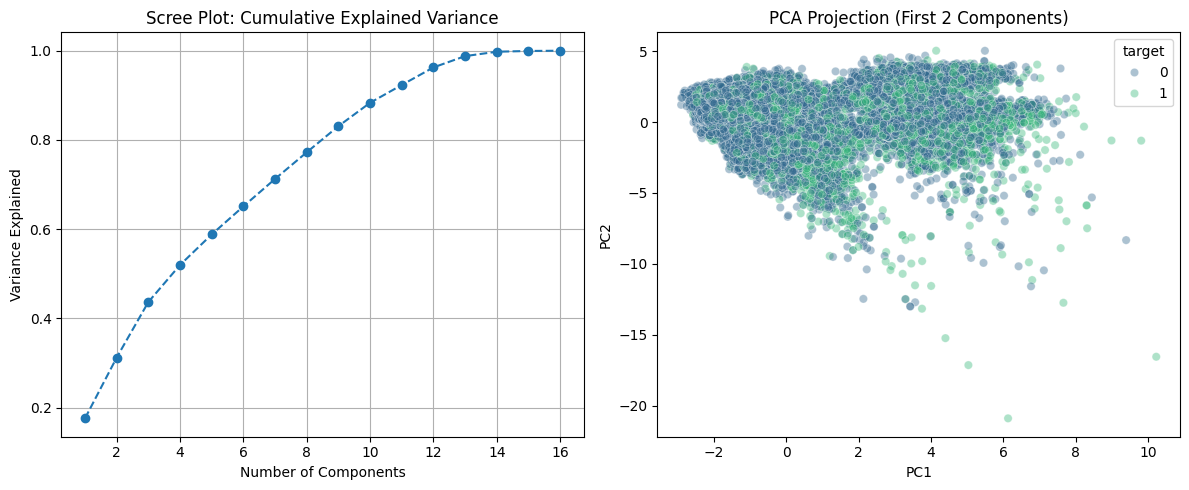

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare features (excluding target)
features = [col for col in df.columns if col != 'target']
X = df[features]
y = df['target']

# 2. Scaling is MANDATORY for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Visualization: Scree Plot (to check for noise)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)

# 5. Visualization: 2D Projection (to check for class separation)
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(X_pca), size=min(100000, len(X_pca)), replace=False)
sns.scatterplot(x=X_pca[sample_idx, 0], y=X_pca[sample_idx, 1],
                hue=y.iloc[sample_idx], alpha=0.4, palette='viridis')
plt.title('PCA Projection (First 2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### PCA Observations:
As see in the PCA analysis, there is significant overlap in how the first and second components explains delay vs on-time. This clearly shows that the current input features are not sufficient for the model to make a good prediction. Our next step based on this analysis is to do some additional data processing work and include additional features into the model.

# New Improved Data for Training

In [6]:
query_1st_improv = """
  SELECT
      -- 2. Cyclical Encoding (Replacing raw MONTH and DEP_HOUR)
      f.DAY_OF_MONTH,
      f.DISTANCE,
      SIN(2 * PI() * f.MONTH / 12) AS MONTH_SIN,
      COS(2 * PI() * f.MONTH / 12) AS MONTH_COS,
      SIN(2 * PI() * CAST(f.CRS_DEP_TIME / 100 AS BIGINT) / 24) AS DEP_HOUR_SIN,
      COS(2 * PI() * CAST(f.CRS_DEP_TIME / 100 AS BIGINT) / 24) AS DEP_HOUR_COS,

      -- ORIGIN AND DESTINATION AIRPORT
      f.ORIGIN,
      f.DEST,

      -- 3B. Airport Traffic / Congestion (Count of flights leaving same airport at same hour)
      COUNT(*) OVER (
          PARTITION BY f.ORIGIN, f.YEAR, f.MONTH, f.DAY_OF_MONTH, CAST(f.CRS_DEP_TIME / 100 AS BIGINT)
      ) AS ORIGIN_HOURLY_TRAFFIC,

      -- Origin Weather Features
      COALESCE(w.WIND_SPEED, 0) AS ORIGIN_WIND_SPEED,
      COALESCE(w.WIND_GUST, 0) AS ORIGIN_WIND_GUST,
      COALESCE(w.WIND_ANGLE, 0) AS ORIGIN_WIND_ANGLE,
      COALESCE(w.VISIBILITY, 10) AS ORIGIN_VISIBILITY,
      COALESCE(w.AIR_TEMP, 20) AS ORIGIN_AIR_TEMP,
      COALESCE(w.DEW_POINT_TEMP, w.AIR_TEMP) AS ORIGIN_DEW_POINT_TEMP,
      COALESCE(w.PRESSURE, 1013.25) AS ORIGIN_PRESSURE,
      COALESCE(w.PRECIPITATION, 0) AS ORIGIN_PRECIPITATION,

      -- 1. Fix Ceiling Height
      CASE WHEN w.CEILING_HEIGHT = 99999 THEN 1 ELSE 0 END AS ORIGIN_IS_CLEAR_CEILING,
      LEAST(COALESCE(w.CEILING_HEIGHT, 20000), 20000) AS ORIGIN_CEILING_HEIGHT,

      COALESCE(w.HAS_THUNDERSTORM, 0) AS ORIGIN_HAS_THUNDERSTORM,
      COALESCE(w.HAS_GUST, 0) AS ORIGIN_HAS_GUST,
      COALESCE(w.HAS_CLOUDS, 0) AS ORIGIN_HAS_CLOUDS,

      -- 3A. Destination Weather Features (Crucial for predicting delays)
      COALESCE(w_dest.WIND_SPEED, 0) AS DEST_WIND_SPEED,
      COALESCE(w_dest.VISIBILITY, 10) AS DEST_VISIBILITY,
      COALESCE(w_dest.PRECIPITATION, 0) AS DEST_PRECIPITATION,
      CASE WHEN w_dest.CEILING_HEIGHT = 99999 THEN 1 ELSE 0 END AS DEST_IS_CLEAR_CEILING,
      LEAST(COALESCE(w_dest.CEILING_HEIGHT, 20000), 20000) AS DEST_CEILING_HEIGHT,
      COALESCE(w_dest.HAS_THUNDERSTORM, 0) AS DEST_HAS_THUNDERSTORM,

      f.ARRIVAL_DELAYED AS target

  FROM flights_cleaned f

  -- Join for Origin Weather
  LEFT JOIN weather_db.weather_cleaned w
      ON f.ORIGIN = w.STATION
      AND f.YEAR = w.YEAR
      AND f.MONTH = w.MONTH
      AND f.DAY_OF_MONTH = w.DAY
      AND CAST(f.CRS_DEP_TIME / 100 AS BIGINT) = w.HOUR

  -- Join for Destination Weather
  LEFT JOIN weather_db.weather_cleaned w_dest
      ON f.DEST = w_dest.STATION
      AND f.YEAR = w_dest.YEAR
      AND f.MONTH = w_dest.MONTH
      AND f.DAY_OF_MONTH = w_dest.DAY
      -- We join on estimated arrival hour to see what the weather will be like when they land
      AND CAST(f.CRS_ARR_TIME / 100 AS BIGINT) = w_dest.HOUR

  WHERE f.ARRIVAL_DELAYED IS NOT NULL
    AND f.CANCELLED = 0
"""
df_1st_improv = con.execute(query_1st_improv).fetchdf()

# Drop rows with any NaNs (including our problematic dew points)
df_1st_improv = df_1st_improv.dropna()

print(f"Cleaned dataset shape: {df_1st_improv.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cleaned dataset shape: (11565665, 29)


Compared to cleaned dataset shape: (11565665, 17) in original PCA, there are 12 more features now.

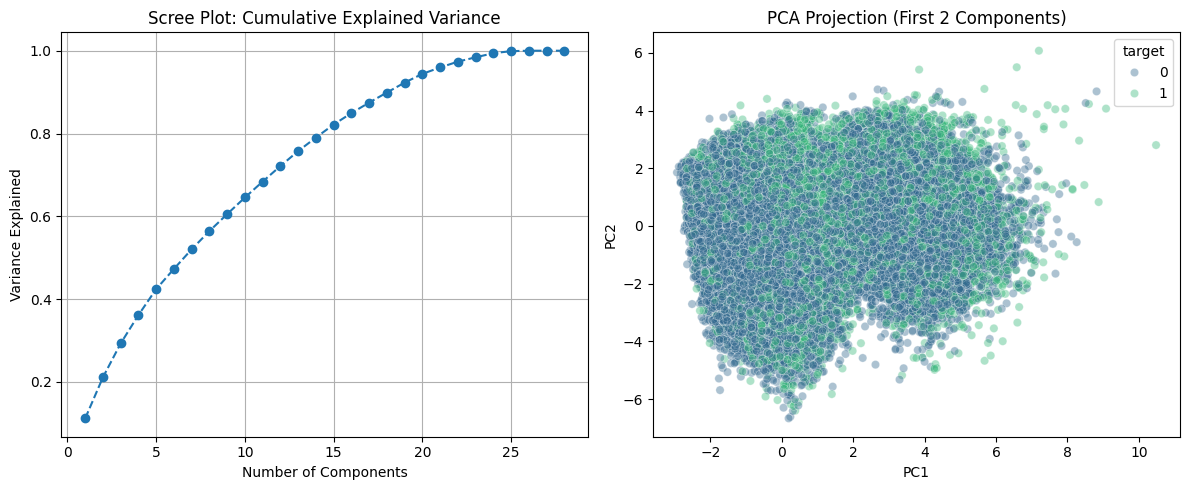

In [7]:
# ==========================================
# 0. Handle Categorical Strings
# ==========================================
# PCA cannot process strings like 'JFK' or 'LAX'.
# We convert them to numbers based on how many flights go through them (Frequency Encoding).

origin_counts = df_1st_improv['ORIGIN'].value_counts()
df_1st_improv['ORIGIN_FREQ'] = df_1st_improv['ORIGIN'].map(origin_counts)

dest_counts = df_1st_improv['DEST'].value_counts()
df_1st_improv['DEST_FREQ'] = df_1st_improv['DEST'].map(dest_counts)

# Drop the string columns so we are left with only numbers
df_1st_improv = df_1st_improv.drop(columns=['ORIGIN', 'DEST'])

# ==========================================
# 1. Prepare features (excluding target)
# ==========================================
features = [col for col in df_1st_improv.columns if col != 'target']
X = df_1st_improv[features]
y = df_1st_improv['target']

# ==========================================
# 2. Scaling is MANDATORY for PCA
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. Fit PCA
# ==========================================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# ==========================================
# 4. Visualization: Scree Plot
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)

# ==========================================
# 5. Visualization: 2D Projection
# ==========================================
plt.subplot(1, 2, 2)
# Tip: If your dataset is >100k rows, plotting all points will be very slow and look like a giant blob.
sample_size = min(100000, len(X_pca))
sample_idx = np.random.choice(len(X_pca), size=sample_size, replace=False)

sns.scatterplot(x=X_pca[sample_idx, 0], y=X_pca[sample_idx, 1],
                hue=y.iloc[sample_idx], alpha=0.4, palette='viridis')
plt.title('PCA Projection (First 2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()